# Introduction

This notebook is example of running simulation with package `LSolver`, and also test with well-known result of statistical mechanics. Consider overdamped Langevin equation of the form
$$\dot x_t = -\frac{k}{\gamma}x_t + \sqrt{2D}\xi_t,$$
which follows from inserting the stochastic Brownian particle in a harmonic potential $U(x) = \frac{1}{2}kx^2$. This equation could be discretized as
$$x(t + \text{d}t) - x(t) = - \frac{k}{\gamma}x_t \text{d}t + \sqrt{2D\,\text{d}t}\,W_{\text{d}t}^1,$$
where $W_{\text{d}t}^1$ is a random number from the standard normal distribution $\mathcal N(0,1)$.

Using the package `LSolver`, we can simulate the particle trajectory (with selected parameters $k=1$, $\gamma = 1$, $D = 10$):

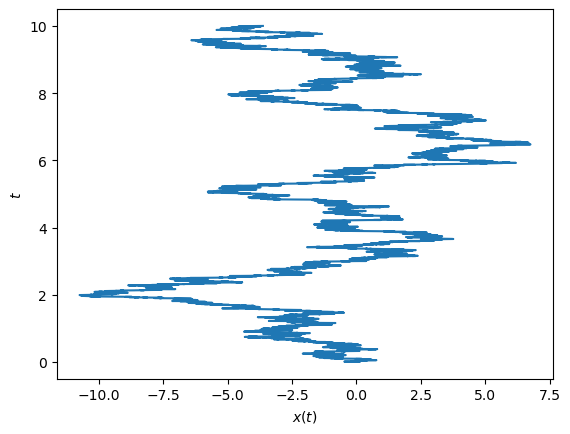

In [1]:
from LSolver import SimulationConfig, solver
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
cfg = SimulationConfig(
    gamma = 1.0,
    k_func = lambda t: 1.0,
    D_func = lambda t: 10.0,
    t_max = 10.0,
    dt = 0.001
    )

x, y = solver(cfg, rng=rng)

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x(t)$", ylabel=r"$t$")
ax.plot(x,cfg.t_array)

Instead of physical time $t$, we can use stochastic time variable $y(t)$ governed by equation
$$y(t+\text{d}t) - y(t) = \sqrt{2D\,\text{d}t}\, W_{\text{d}t}^1.$$
The expected property of this time is
$$\langle \Delta y \rangle = 0, \quad \langle(\Delta y)^2\rangle = 2D\,\text{d}t.$$
Same solution in terms of $y(t)$ looks like this:

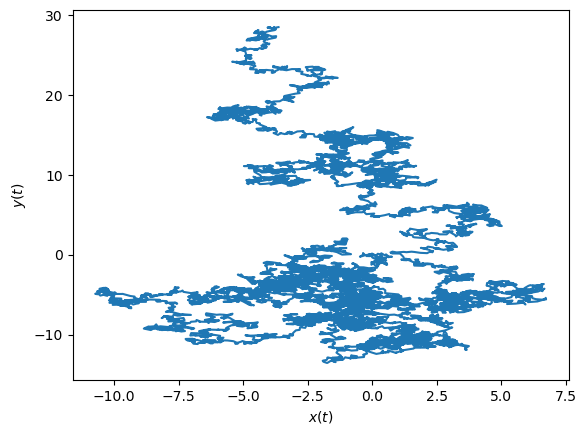

In [2]:
fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x(t)$", ylabel=r"$y(t)$")
ax.plot(x,y)

# Stationary state validation

In the above simulation, we have set $k(t) \equiv k, D(t) \equiv D$. The Diffusion coefficient $D$ is related to the friction coefficient $\gamma$ and the inverse temperature $\beta$ through equation $D\beta \gamma = 1$. 

In this regime, the system after some time relaxes to a stationary state with the Boltzmann probability distribution
$$P(x) = \frac{1}{Z}e^{-\beta \frac{1}{2}kx^2}.$$
Furthermore, assuming $x(0) = 0$, it could be derived that the mean is
$$\langle x(t) \rangle = 0$$
and the mean squared deviation is
$$\langle x(t)^2 \rangle = \frac{D\gamma}{k}\left(1-e^{-2kt/\gamma}\right).$$
Also note that the characteristic relaxation time of this system is
$$\tau_R = \frac{\gamma}{k}.$$

## Ensemble interpretation of statistical physics

The function $P(x)$ might be interpreted as follows: Let us have a large number of imaginary systems with the same properties, initial and boundary conditions. Then, after long enough time, the quantity $P(x)\Delta x$ measures how many of these systems are in the configuration inside the interval $(x, x+\Delta x)$.

This interpretation is useful, because now we can run many simulations and check whether after some time, they will arrange corresponding to the function $P(x)$. In fact, the normalization constant $Z$ (which is usually called partition function) could be easily evaluated, because $\int P(x) \text d x$ is Gaussian integral. The normalized function is
$$P(x) = \sqrt{\frac{k\beta}{2\pi}}\exp\left(-\frac{1}{2}k\beta x^2\right).$$

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.82it/s]


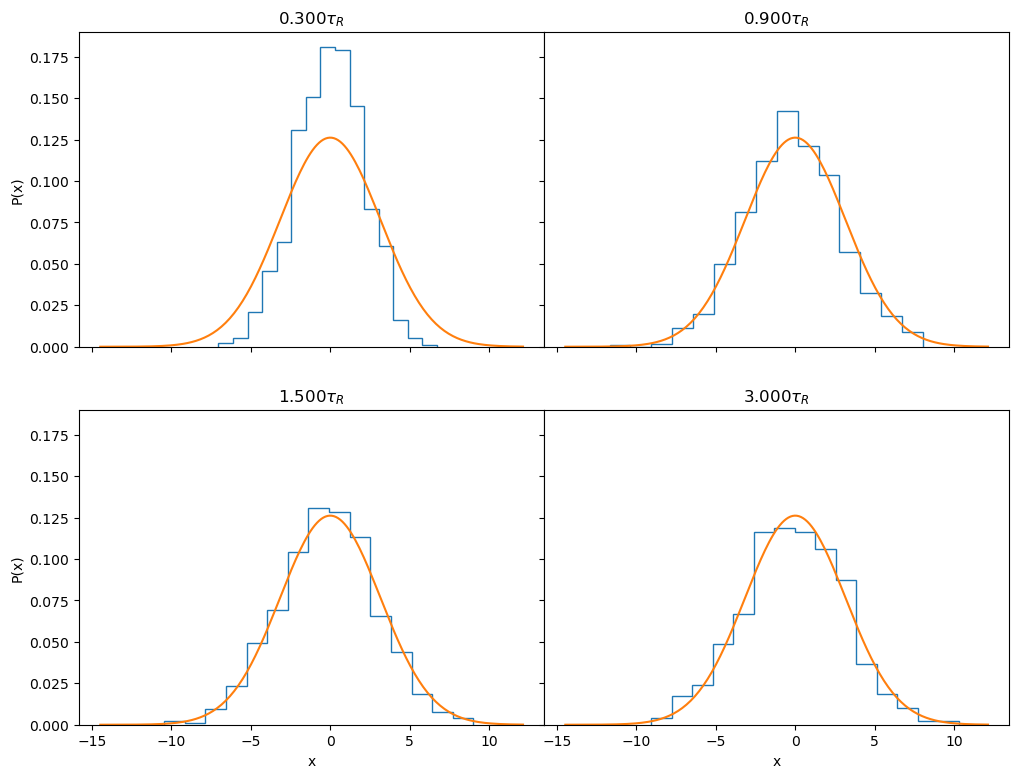

In [3]:
from tqdm import tqdm #optional import for progressbar

rng = np.random.default_rng(seed=2048)

N = 1000
k0 = 1.0
D0 = 10.0

cfg = SimulationConfig(
    gamma = 1.0,
    k_func = lambda t: k0,
    D_func = lambda t: D0,
    t_max = 3.0,
    dt = 0.0001
    )

data = np.empty(shape=(N,len(cfg.t_array)))
beta = 1/(D0 * cfg.gamma)

for k in tqdm(range(N)):
    data[k] = solver(cfg, rng=rng)[0]

x = np.linspace(np.min(data), np.max(data), 200)
P = np.sqrt(k0 * beta / 2 / np.pi) * np.exp(- beta * k0 * x ** 2 / 2)

fig, axs = plt.subplots(2,2, figsize=(12,9), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0)
axs[0,0].set_ylabel(r"P(x)"), axs[1,0].set(xlabel=r"x", ylabel=r"P(x)"), axs[1,1].set_xlabel(r"x")

for n,k in enumerate([0.1,0.3,0.5,1.0]):
    num = int(k * len(cfg.t_array)) - 1
    counts, bins = np.histogram(data[:,num], density=True, bins=15)
    if n <= 1:
        axs[0,n].stairs(counts, bins)
        axs[0,n].set_title(label=r"{kk:.3f}$\tau_R$".format(kk=k*cfg.t_max))
        axs[0,n].plot(x,P)
    else:
        axs[1,n-2].stairs(counts, bins)
        axs[1,n-2].set_title(label=r"{kk:.3f}$\tau_R$".format(kk=k*cfg.t_max))
        axs[1,n-2].plot(x,P)

## The evolution of mean values

Additionaly, we can check the evolution of ensemble mean $\langle x(t)\rangle$.

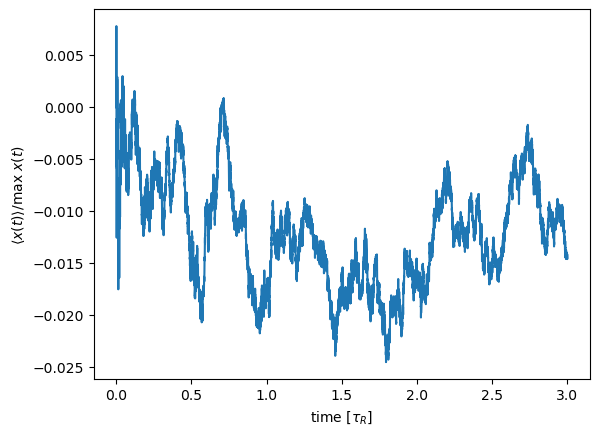

In [4]:
avg = np.empty_like(data[0,:])

avg[0] = 0
avg[1:] = np.mean(data[:, 1:], axis=0) / np.max(data[:, 1:], axis=0)

t = np.array([a*cfg.t_max/(len(avg)-1) for a in range(len(avg))])

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"time [$\tau_R$]", ylabel=r"$\langle x(t)\rangle$/max $x(t)$")
ax.plot(t, avg)

In this sample, values of $|\langle x(t) \rangle / \text{max } x(t)|$ are below $2.5\%$, confirming convergence to zero.

Now, we evaluate mean squared deviation:

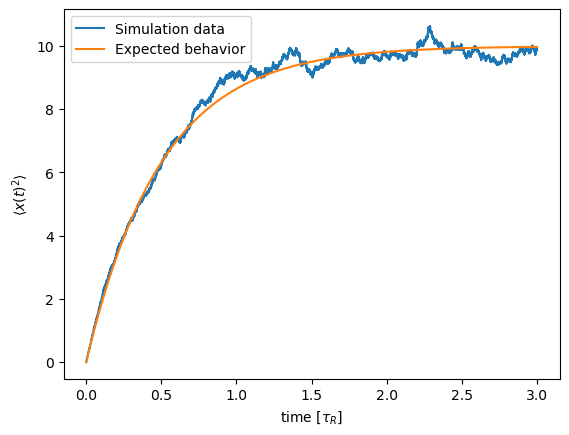

In [5]:
var = np.empty_like(avg)

var = np.mean(data**2, axis=0)

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"time [$\tau_R$]", ylabel=r"$\langle x(t)^2 \rangle$")
ax.plot(t, var, label="Simulation data")

curve = D0 * (1-np.exp(-2*t))
ax.plot(t, curve, label="Expected behavior")
ax.legend(loc="best")